In [1]:
#Install packages and
#Import all needed libraries

!pip install GEOparse
!pip install gseapy
!pip install umap-learn
!pip install scikit-learn
!pip install matplotlib seaborn pandas numpy scipy

import GEOparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import gseapy as gp




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.8/590.8 kB 8.4 MB/s eta 0:00:00


In [2]:
#Fetching GEO datasets
geo_ids = ["GSE18842", "GSE19804", "GSE19188", "GSE31210", "GSE33532"]

datasets = {}

for geo_id in geo_ids:
    print(f"Downloading {geo_id} ...")
    gse = GEOparse.get_GEO(geo=geo_id, destdir="./")
    datasets[geo_id] = gse



30-Apr-2025 01:08:19 DEBUG utils - Directory ./ already exists. Skipping.
DEBUG:GEOparse:Directory ./ already exists. Skipping.
30-Apr-2025 01:08:19 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE18nnn/GSE18842/soft/GSE18842_family.soft.gz to ./GSE18842_family.soft.gz
INFO:GEOparse:Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE18nnn/GSE18842/soft/GSE18842_family.soft.gz to ./GSE18842_family.soft.gz


100%|██████████| 40.7M/40.7M [00:01<00:00, 29.7MB/s]
30-Apr-2025 01:08:21 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
30-Apr-2025 01:08:21 DEBUG downloader - Moving /tmp/tmpim7mexnm to /content/GSE18842_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmpim7mexnm to /content/GSE18842_family.soft.gz
30-Apr-2025 01:08:21 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE18nnn/GSE18842/soft/GSE18842_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE18nnn/GSE18842/soft/GSE18842_family.soft.gz
30-Apr-2025 01:08:21 INFO GEOparse - Parsing ./GSE18842_family.soft.gz: 
INFO:GEOparse:Parsing ./GSE18842_family.soft.gz: 
30-Apr-2025 01:08:21 DEBUG GEOparse - DATABASE: GeoMiame
DEBUG:GEOparse:DATABASE: GeoMiame
30-Apr-2025 01:08:21 DEBUG GEOparse - SERIES: GSE18842
DEBUG:GEOparse:SERIES: GSE18842
30-Apr-2025 01:08:21 DEBUG GEOparse - PLATFORM: GPL570
DEBUG:GEOparse:PLATFORM: GPL570
/usr/local

100%|██████████| 50.6M/50.6M [00:01<00:00, 29.8MB/s]
30-Apr-2025 01:08:38 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
30-Apr-2025 01:08:38 DEBUG downloader - Moving /tmp/tmpspv87n9u to /content/GSE19804_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmpspv87n9u to /content/GSE19804_family.soft.gz
30-Apr-2025 01:08:38 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE19nnn/GSE19804/soft/GSE19804_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE19nnn/GSE19804/soft/GSE19804_family.soft.gz
30-Apr-2025 01:08:38 INFO GEOparse - Parsing ./GSE19804_family.soft.gz: 
INFO:GEOparse:Parsing ./GSE19804_family.soft.gz: 
30-Apr-2025 01:08:38 DEBUG GEOparse - DATABASE: GeoMiame
DEBUG:GEOparse:DATABASE: GeoMiame
30-Apr-2025 01:08:38 DEBUG GEOparse - SERIES: GSE19804
DEBUG:GEOparse:SERIES: GSE19804
30-Apr-2025 01:08:38 DEBUG GEOparse - PLATFORM: GPL570
DEBUG:GEOparse:PLATFORM: GPL570
/usr/local

100%|██████████| 79.8M/79.8M [00:02<00:00, 39.6MB/s]
30-Apr-2025 01:09:02 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
30-Apr-2025 01:09:02 DEBUG downloader - Moving /tmp/tmpdav0vasg to /content/GSE19188_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmpdav0vasg to /content/GSE19188_family.soft.gz
30-Apr-2025 01:09:02 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE19nnn/GSE19188/soft/GSE19188_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE19nnn/GSE19188/soft/GSE19188_family.soft.gz
30-Apr-2025 01:09:02 INFO GEOparse - Parsing ./GSE19188_family.soft.gz: 
INFO:GEOparse:Parsing ./GSE19188_family.soft.gz: 
30-Apr-2025 01:09:02 DEBUG GEOparse - DATABASE: GeoMiame
DEBUG:GEOparse:DATABASE: GeoMiame
30-Apr-2025 01:09:02 DEBUG GEOparse - SERIES: GSE19188
DEBUG:GEOparse:SERIES: GSE19188
30-Apr-2025 01:09:02 DEBUG GEOparse - PLATFORM: GPL570
DEBUG:GEOparse:PLATFORM: GPL570
/usr/local

100%|██████████| 109M/109M [00:02<00:00, 43.8MB/s]
30-Apr-2025 01:09:28 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
30-Apr-2025 01:09:28 DEBUG downloader - Moving /tmp/tmpz0xy0q3v to /content/GSE31210_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmpz0xy0q3v to /content/GSE31210_family.soft.gz
30-Apr-2025 01:09:29 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE31nnn/GSE31210/soft/GSE31210_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE31nnn/GSE31210/soft/GSE31210_family.soft.gz
30-Apr-2025 01:09:29 INFO GEOparse - Parsing ./GSE31210_family.soft.gz: 
INFO:GEOparse:Parsing ./GSE31210_family.soft.gz: 
30-Apr-2025 01:09:29 DEBUG GEOparse - DATABASE: GeoMiame
DEBUG:GEOparse:DATABASE: GeoMiame
30-Apr-2025 01:09:29 DEBUG GEOparse - SERIES: GSE31210
DEBUG:GEOparse:SERIES: GSE31210
30-Apr-2025 01:09:29 DEBUG GEOparse - PLATFORM: GPL570
DEBUG:GEOparse:PLATFORM: GPL570
/usr/local/l

100%|██████████| 32.9M/32.9M [00:01<00:00, 25.9MB/s]
30-Apr-2025 01:10:05 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
30-Apr-2025 01:10:05 DEBUG downloader - Moving /tmp/tmptq975s4s to /content/GSE33532_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmptq975s4s to /content/GSE33532_family.soft.gz
30-Apr-2025 01:10:05 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE33nnn/GSE33532/soft/GSE33532_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE33nnn/GSE33532/soft/GSE33532_family.soft.gz
30-Apr-2025 01:10:05 INFO GEOparse - Parsing ./GSE33532_family.soft.gz: 
INFO:GEOparse:Parsing ./GSE33532_family.soft.gz: 
30-Apr-2025 01:10:05 DEBUG GEOparse - DATABASE: GeoMiame
DEBUG:GEOparse:DATABASE: GeoMiame
30-Apr-2025 01:10:05 DEBUG GEOparse - SERIES: GSE33532
DEBUG:GEOparse:SERIES: GSE33532
30-Apr-2025 01:10:05 DEBUG GEOparse - PLATFORM: GPL570
DEBUG:GEOparse:PLATFORM: GPL570
/usr/local

In [ ]:
#Garbage block

'''#Preprocessing and Normalization

def get_expression_matrix(gse_obj):
    samples = gse_obj.gsms
    expr_df = pd.DataFrame()

    for gsm_name, gsm in samples.items():
        table = gsm.table
        if 'ID_REF' in table.columns and 'VALUE' in table.columns:
            expr_df[gsm_name] = table.set_index('ID_REF')['VALUE']
    return expr_df

for geo_id, gse_obj in datasets.items():
    print(f"Processing {geo_id} ...")
    expr = get_expression_matrix(gse_obj)

    expr = expr.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
    expression_data[geo_id] = expr

'''


Processing GSE18842 ...
Processing GSE19804 ...


<ipython-input-4-5fb09255ad22>:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  expr_df[gsm_name] = table.set_index('ID_REF')['VALUE']
<ipython-input-4-5fb09255ad22>:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  expr_df[gsm_name] = table.set_index('ID_REF')['VALUE']
<ipython-input-4-5fb09255ad22>:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a d

Processing GSE19188 ...


<ipython-input-4-5fb09255ad22>:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  expr_df[gsm_name] = table.set_index('ID_REF')['VALUE']
<ipython-input-4-5fb09255ad22>:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  expr_df[gsm_name] = table.set_index('ID_REF')['VALUE']
<ipython-input-4-5fb09255ad22>:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a d

Processing GSE31210 ...


<ipython-input-4-5fb09255ad22>:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  expr_df[gsm_name] = table.set_index('ID_REF')['VALUE']
<ipython-input-4-5fb09255ad22>:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  expr_df[gsm_name] = table.set_index('ID_REF')['VALUE']
<ipython-input-4-5fb09255ad22>:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a d

Processing GSE33532 ...


In [3]:
#Preprocessing and Normalization

def get_expression_matrix(gse_obj):
    samples = gse_obj.gsms
    expr_list = []
    sample_names = []

    for gsm_name, gsm in samples.items():
        table = gsm.table
        if 'ID_REF' in table.columns and 'VALUE' in table.columns:
            expr_series = table.set_index('ID_REF')['VALUE']
            expr_list.append(expr_series)
            sample_names.append(gsm_name)

#Concatenating all samples at once
    expr_df = pd.concat(expr_list, axis=1)
    expr_df.columns = sample_names

    return expr_df

#Extracting expression matrices
expression_data = {}

for geo_id, gse_obj in datasets.items():
    print(f"Processing {geo_id} ...")
    expr = get_expression_matrix(gse_obj)
#Normalize: Z-score normalization across samples
    expr = expr.apply(lambda x: (x - x.mean()) / x.std(), axis=0)
    expression_data[geo_id] = expr



Processing GSE18842 ...
Processing GSE19804 ...
Processing GSE19188 ...
Processing GSE31210 ...
Processing GSE33532 ...


In [4]:
sample_labels = {}

#Define simple keyword , so that it will create auto lables
def detect_label(text):
    text = str(text).lower()
    if "normal" in text or "non-tumor" in text or "adjacent normal" in text:
        return "Normal"
    elif "tumor" in text or "cancer" in text or "adenocarcinoma" in text:
        return "Tumor"
    else:
        return "Unknown"

#Loop through all datasets
for geo_id, gse_obj in datasets.items():
    labels = {}
    pheno = gse_obj.phenotype_data

    #Prefer columns if available ( You can select coluns that you preferd)
    possible_cols = ['source_name_ch1', 'title', 'characteristics_ch1', 'characteristics_ch1.1']
    found_col = None

    for col in possible_cols:
        if col in pheno.columns:
            found_col = col
            break

    if found_col:
        print(f"Using {found_col} for labeling {geo_id}")

        for gsm_name, row in pheno.iterrows():
            label = detect_label(row[found_col])
            if label != "Unknown":
                labels[gsm_name] = label

    sample_labels[geo_id] = labels




Using source_name_ch1 for labeling GSE18842
Using source_name_ch1 for labeling GSE19804
Using source_name_ch1 for labeling GSE19188
Using source_name_ch1 for labeling GSE31210
Using source_name_ch1 for labeling GSE33532


In [5]:
#Now I am doing DEG Analysis (with correct sample_labels)

deg_results = {}

for geo_id, expr in expression_data.items():
    if geo_id in sample_labels:
        print(f"Running DEG analysis for {geo_id} ...")

        #Select Tumor and Normal samples based on labels
        tumor_samples = [s for s, label in sample_labels[geo_id].items() if label == "Tumor" and s in expr.columns]
        normal_samples = [s for s, label in sample_labels[geo_id].items() if label == "Normal" and s in expr.columns]

        print(f" Tumor samples: {len(tumor_samples)}, Normal samples: {len(normal_samples)}")

        if len(tumor_samples) >= 2 and len(normal_samples) >= 2:
            deg_df = pd.DataFrame(index=expr.index)

            pvalues = []
            logfc = []

            for gene in expr.index:
                #Perform two-sample t-test
                stat, pval = stats.ttest_ind(
                    expr.loc[gene, tumor_samples],
                    expr.loc[gene, normal_samples],
                    equal_var=False,
                    nan_policy='omit'
                )
                pvalues.append(pval)

                #Calculate log2 Fold Change
                lfc = np.log2(expr.loc[gene, tumor_samples].mean() + 1e-9) - np.log2(expr.loc[gene, normal_samples].mean() + 1e-9)
                logfc.append(lfc)

            deg_df["pvalue"] = pvalues
            deg_df["logFC"] = logfc

            #Adjust p-values later using FDR if you want (this is optional step)
            deg_results[geo_id] = deg_df

        else:
            print(f"⚠️ Skipping {geo_id} due to insufficient samples after labeling.")



Running DEG analysis for GSE18842 ...
 Tumor samples: 46, Normal samples: 0
⚠️ Skipping GSE18842 due to insufficient samples after labeling.
Running DEG analysis for GSE19804 ...
 Tumor samples: 60, Normal samples: 60


Streaming output truncated to the last 5000 lines.
<ipython-input-5-8dbdcf1a6a8b>:32: RuntimeWarning: invalid value encountered in log2
  lfc = np.log2(expr.loc[gene, tumor_samples].mean() + 1e-9) - np.log2(expr.loc[gene, normal_samples].mean() + 1e-9)
<ipython-input-5-8dbdcf1a6a8b>:32: RuntimeWarning: invalid value encountered in log2
  lfc = np.log2(expr.loc[gene, tumor_samples].mean() + 1e-9) - np.log2(expr.loc[gene, normal_samples].mean() + 1e-9)
<ipython-input-5-8dbdcf1a6a8b>:32: RuntimeWarning: invalid value encountered in log2
  lfc = np.log2(expr.loc[gene, tumor_samples].mean() + 1e-9) - np.log2(expr.loc[gene, normal_samples].mean() + 1e-9)
<ipython-input-5-8dbdcf1a6a8b>:32: RuntimeWarning: invalid value encountered in log2
  lfc = np.log2(expr.loc[gene, tumor_samples].mean() + 1e-9) - np.log2(expr.loc[gene, normal_samples].mean() + 1e-9)
<ipython-input-5-8dbdcf1a6a8b>:32: RuntimeWarning: invalid value encountered in log2
  lfc = np.log2(expr.loc[gene, tumor_samples].mean() + 1

Running DEG analysis for GSE19188 ...
 Tumor samples: 0, Normal samples: 0
⚠️ Skipping GSE19188 due to insufficient samples after labeling.
Running DEG analysis for GSE31210 ...
 Tumor samples: 226, Normal samples: 20


Streaming output truncated to the last 5000 lines.
<ipython-input-5-8dbdcf1a6a8b>:32: RuntimeWarning: invalid value encountered in log2
  lfc = np.log2(expr.loc[gene, tumor_samples].mean() + 1e-9) - np.log2(expr.loc[gene, normal_samples].mean() + 1e-9)
<ipython-input-5-8dbdcf1a6a8b>:32: RuntimeWarning: invalid value encountered in log2
  lfc = np.log2(expr.loc[gene, tumor_samples].mean() + 1e-9) - np.log2(expr.loc[gene, normal_samples].mean() + 1e-9)
<ipython-input-5-8dbdcf1a6a8b>:32: RuntimeWarning: invalid value encountered in log2
  lfc = np.log2(expr.loc[gene, tumor_samples].mean() + 1e-9) - np.log2(expr.loc[gene, normal_samples].mean() + 1e-9)
<ipython-input-5-8dbdcf1a6a8b>:32: RuntimeWarning: invalid value encountered in log2
  lfc = np.log2(expr.loc[gene, tumor_samples].mean() + 1e-9) - np.log2(expr.loc[gene, normal_samples].mean() + 1e-9)
<ipython-input-5-8dbdcf1a6a8b>:32: RuntimeWarning: invalid value encountered in log2
  lfc = np.log2(expr.loc[gene, tumor_samples].mean() + 1

Running DEG analysis for GSE33532 ...
 Tumor samples: 80, Normal samples: 20


Streaming output truncated to the last 5000 lines.
<ipython-input-5-8dbdcf1a6a8b>:32: RuntimeWarning: invalid value encountered in log2
  lfc = np.log2(expr.loc[gene, tumor_samples].mean() + 1e-9) - np.log2(expr.loc[gene, normal_samples].mean() + 1e-9)
<ipython-input-5-8dbdcf1a6a8b>:32: RuntimeWarning: invalid value encountered in log2
  lfc = np.log2(expr.loc[gene, tumor_samples].mean() + 1e-9) - np.log2(expr.loc[gene, normal_samples].mean() + 1e-9)
<ipython-input-5-8dbdcf1a6a8b>:32: RuntimeWarning: invalid value encountered in log2
  lfc = np.log2(expr.loc[gene, tumor_samples].mean() + 1e-9) - np.log2(expr.loc[gene, normal_samples].mean() + 1e-9)
<ipython-input-5-8dbdcf1a6a8b>:32: RuntimeWarning: invalid value encountered in log2
  lfc = np.log2(expr.loc[gene, tumor_samples].mean() + 1e-9) - np.log2(expr.loc[gene, normal_samples].mean() + 1e-9)
<ipython-input-5-8dbdcf1a6a8b>:32: RuntimeWarning: invalid value encountered in log2
  lfc = np.log2(expr.loc[gene, tumor_samples].mean() + 1

In [ ]:


"""
def volcano_plot(deg_df, title):
    plt.figure(figsize=(8,6))
    plt.scatter(deg_df['logFC'], -np.log10(deg_df['pvalue']), alpha=0.5)
    plt.axhline(y=-np.log10(0.05), color='red', linestyle='--')
    plt.axvline(x=1, color='green', linestyle='--')
    plt.axvline(x=-1, color='green', linestyle='--')
    plt.title(title)
    plt.xlabel('log2 Fold Change')
    plt.ylabel('-log10 p-value')
    plt.show()

for geo_id, deg_df in deg_results.items():
    volcano_plot(deg_df, f"Volcano Plot - {geo_id}")

"""


'# STEP 6: Volcano Plots for each dataset\n\ndef volcano_plot(deg_df, title):\n    plt.figure(figsize=(8,6))\n    plt.scatter(deg_df[\'logFC\'], -np.log10(deg_df[\'pvalue\']), alpha=0.5)\n    plt.axhline(y=-np.log10(0.05), color=\'red\', linestyle=\'--\')\n    plt.axvline(x=1, color=\'green\', linestyle=\'--\')\n    plt.axvline(x=-1, color=\'green\', linestyle=\'--\')\n    plt.title(title)\n    plt.xlabel(\'log2 Fold Change\')\n    plt.ylabel(\'-log10 p-value\')\n    plt.show()\n\nfor geo_id, deg_df in deg_results.items():\n    volcano_plot(deg_df, f"Volcano Plot - {geo_id}")\n\n# ✅ Volcano plots done'

Diffrent color Volcano Plot

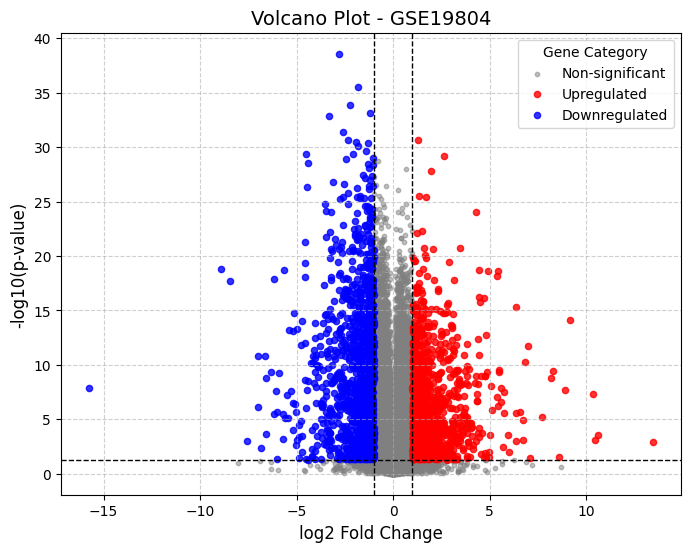

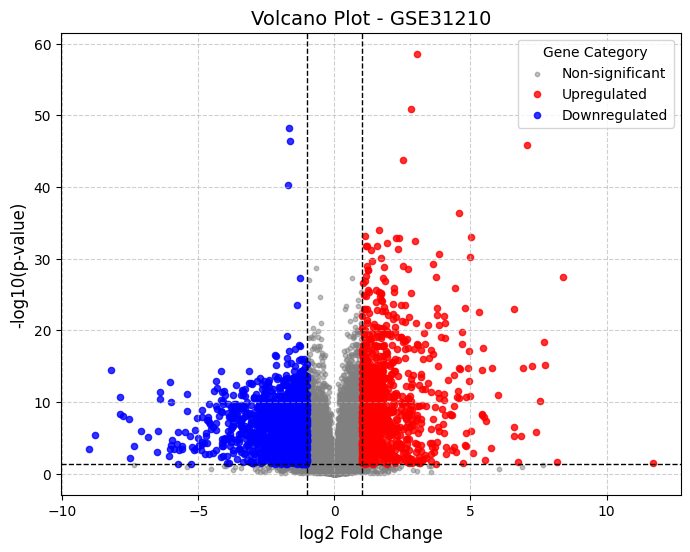

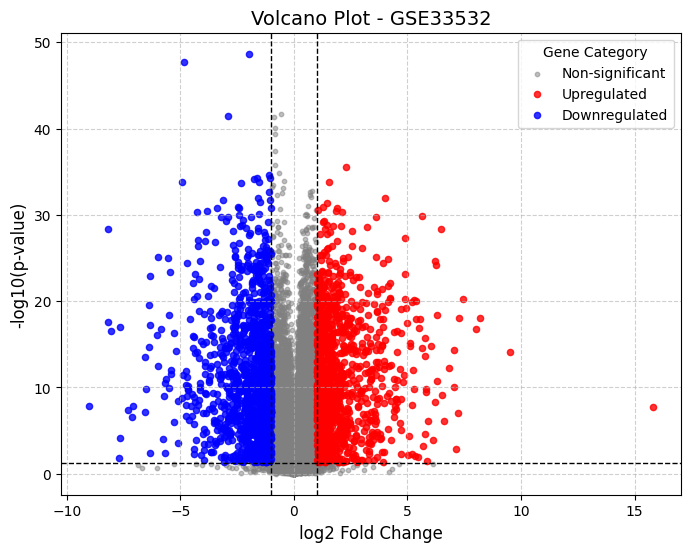

In [ ]:
#Now I am plotting volcano Plots across all datasets

def volcano_plot_fixed_colors(deg_df, title):
    #Createing threshold masks
    sig_up = (deg_df['pvalue'] < 0.05) & (deg_df['logFC'] > 1)
    sig_down = (deg_df['pvalue'] < 0.05) & (deg_df['logFC'] < -1)
    nonsig = ~(sig_up | sig_down)

    plt.figure(figsize=(8,6))

    #Non-significant genes
    plt.scatter(deg_df.loc[nonsig, 'logFC'], -np.log10(deg_df.loc[nonsig, 'pvalue']),
                color="grey", alpha=0.5, s=10, label="Non-significant")

    #Upregulated
    plt.scatter(deg_df.loc[sig_up, 'logFC'], -np.log10(deg_df.loc[sig_up, 'pvalue']),
                color="red", alpha=0.8, s=20, label="Upregulated")

    #Downregulated
    plt.scatter(deg_df.loc[sig_down, 'logFC'], -np.log10(deg_df.loc[sig_down, 'pvalue']),
                color="blue", alpha=0.8, s=20, label="Downregulated")

    #Plotting Threshold lines
    plt.axhline(y=-np.log10(0.05), color='black', linestyle='--', linewidth=1)
    plt.axvline(x=1, color='black', linestyle='--', linewidth=1)
    plt.axvline(x=-1, color='black', linestyle='--', linewidth=1)

    plt.title(f"Volcano Plot - {title}", fontsize=14)
    plt.xlabel('log2 Fold Change', fontsize=12)
    plt.ylabel('-log10(p-value)', fontsize=12)
    plt.legend(title="Gene Category")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

#Now ploting for each dataset
for geo_id, deg_df in deg_results.items():
    volcano_plot_fixed_colors(deg_df, title=geo_id)




PCA and UMAP

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


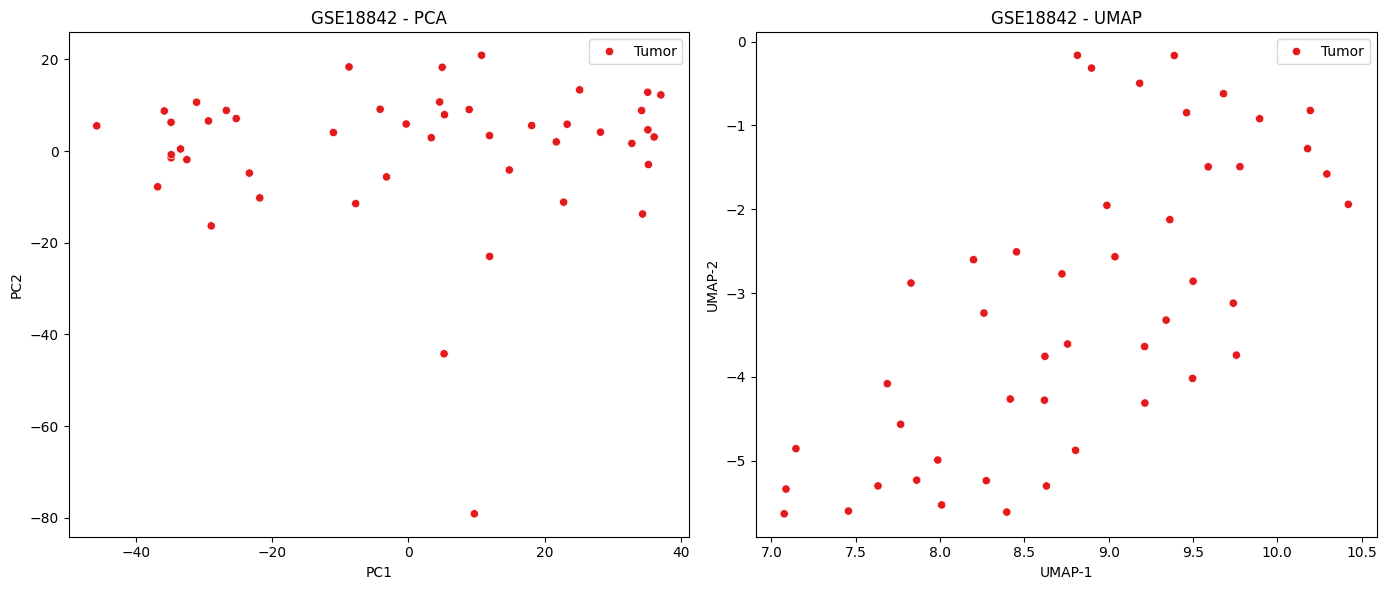

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


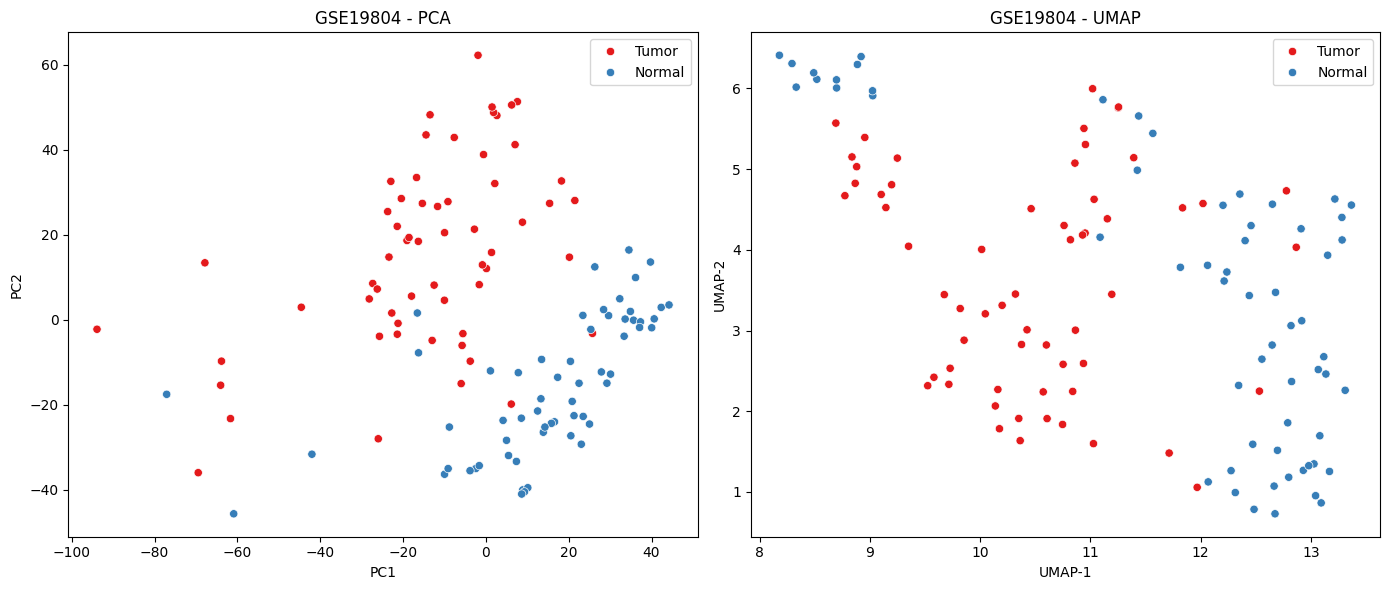

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


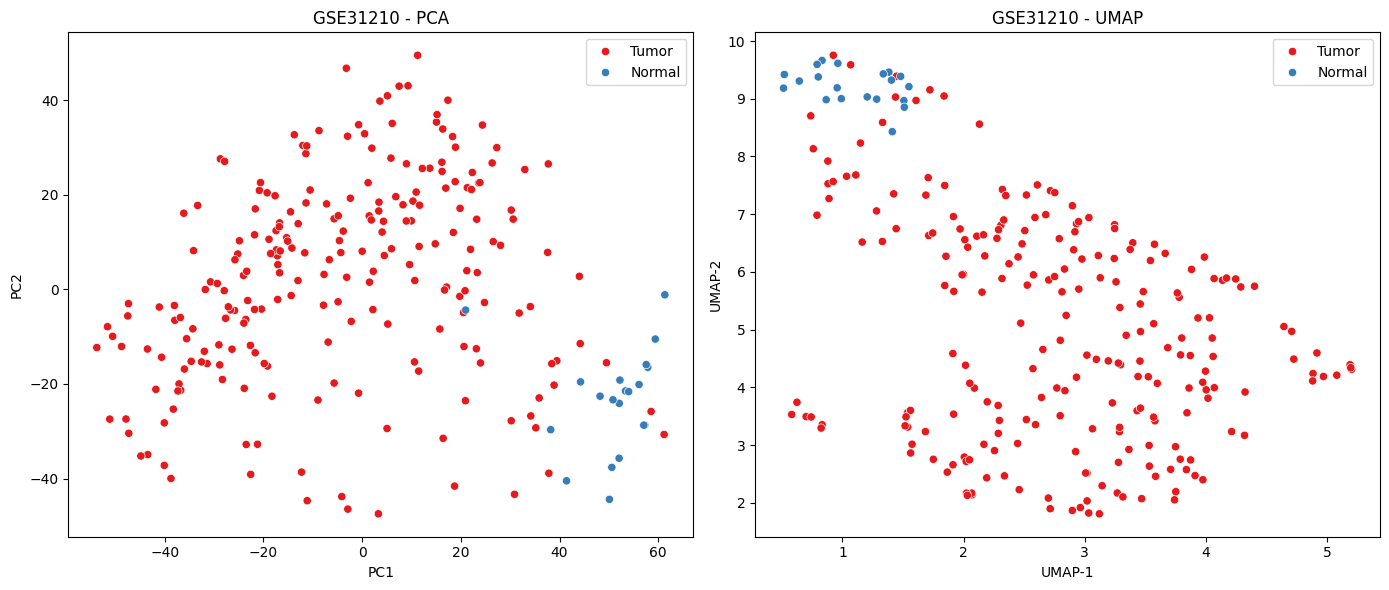

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


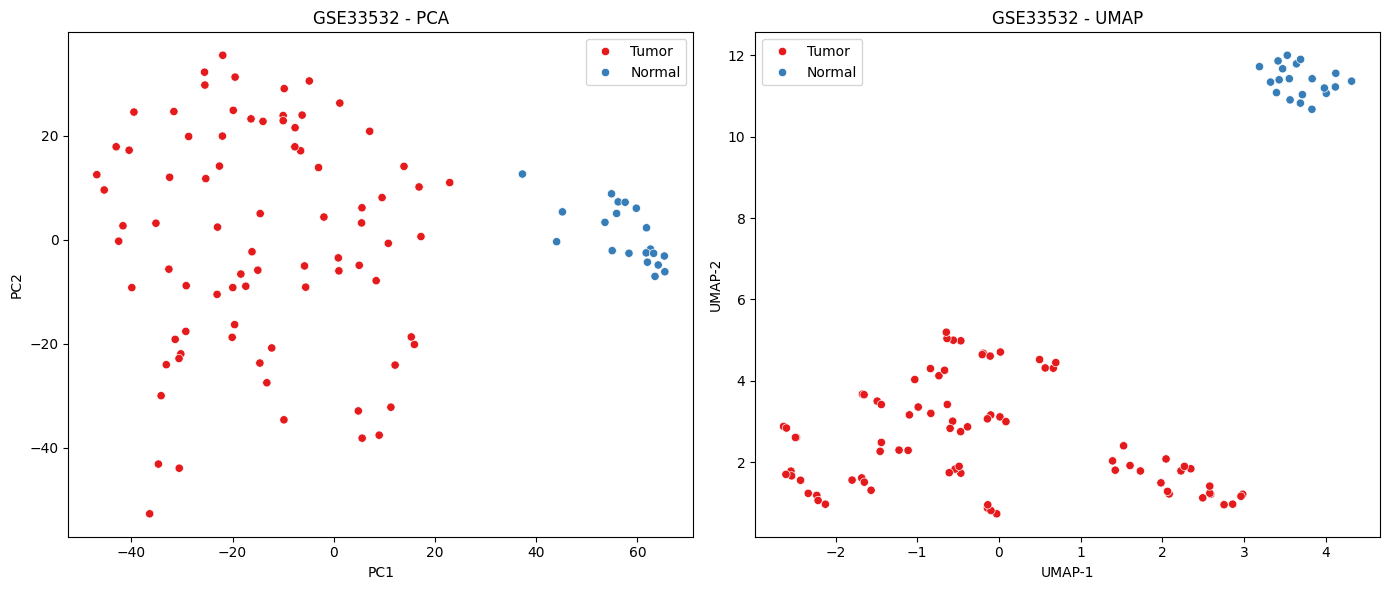

In [ ]:
#Now lets ove to PCA and UMAP Visualization

def plot_pca_umap(expr, labels_dict, title_prefix):
    #Dropping genes with NaN values
    expr_clean = expr.dropna(axis=0, how='any')

    #Matching labels exactly to sample columns
    common_samples = [s for s in expr_clean.columns if s in labels_dict]
    expr_matched = expr_clean[common_samples]
    labels = [labels_dict[sample] for sample in common_samples]

    #PCA
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(expr_matched.T)

    #UMAP
    reducer = umap.UMAP(random_state=42)
    umap_result = reducer.fit_transform(expr_matched.T)

    fig, axes = plt.subplots(1, 2, figsize=(14,6))

    sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=labels, ax=axes[0], palette="Set1")
    axes[0].set_title(f"{title_prefix} - PCA")
    axes[0].set_xlabel('PC1')
    axes[0].set_ylabel('PC2')

    sns.scatterplot(x=umap_result[:,0], y=umap_result[:,1], hue=labels, ax=axes[1], palette="Set1")
    axes[1].set_title(f"{title_prefix} - UMAP")
    axes[1].set_xlabel('UMAP-1')
    axes[1].set_ylabel('UMAP-2')

    plt.tight_layout()
    plt.show()

#Plotting for each dataset
for geo_id, expr in expression_data.items():
    if sample_labels[geo_id]:  # If labels are available
        plot_pca_umap(expr, sample_labels[geo_id], title_prefix=geo_id)



GSE19804: 2187 significant DEGs
GSE31210: 2258 significant DEGs
GSE33532: 2291 significant DEGs


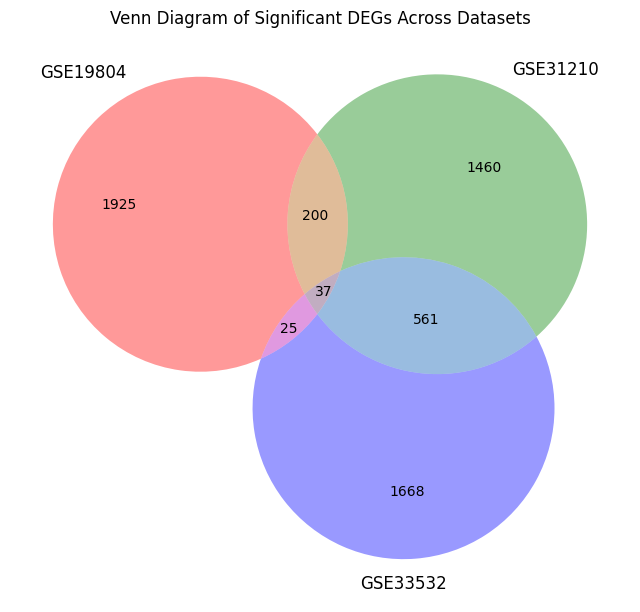

Number of common DEGs across datasets: 37


In [ ]:
#I tried to find common DEGs Across Datasets and Plot Venn Diagram

#First,collect significant genes from each dataset and then define DEG as p-value

deg_gene_sets = {}

for geo_id, deg_df in deg_results.items():
    if geo_id != "GSE18842":
        sig_genes = deg_df[(deg_df['pvalue'] < 0.05) & (abs(deg_df['logFC']) > 1)].index.tolist()
        deg_gene_sets[geo_id] = set(sig_genes)

#Now deg_gene_sets dictionary contains significant genes for each dataset.

#printing to see significNT genes
for geo_id, genes in deg_gene_sets.items():
    print(f"{geo_id}: {len(genes)} significant DEGs")

#Now plot Venn Diagram (only if 2-3-4 datasets)
from matplotlib_venn import venn3, venn3_circles, venn2, venn2_circles

#Select only the datasets we have
selected_datasets = list(deg_gene_sets.keys())

if len(selected_datasets) == 3:
    plt.figure(figsize=(8,8))
    venn3([deg_gene_sets[selected_datasets[0]],
           deg_gene_sets[selected_datasets[1]],
           deg_gene_sets[selected_datasets[2]]],
          set_labels=(selected_datasets[0], selected_datasets[1], selected_datasets[2]))
    plt.title("Venn Diagram of Significant DEGs Across Datasets")
    plt.show()

elif len(selected_datasets) == 4:
    print("4-way Venn Diagram is complicated to plot.")
else:
    print("Only 2 datasets, Venn2 will be plotted.")

#Common DEGs can be found like this
common_genes = set.intersection(*deg_gene_sets.values())

print(f"Number of common DEGs across datasets: {len(common_genes)}")


Got 37 DEGs

In [ ]:
print("Checking DEGs found per dataset:")
for geo_id, deg_df in deg_results.items():
    if geo_id != "GSE18842":
        sig_genes = deg_df[(deg_df['pvalue'] < 0.05) & (abs(deg_df['logFC']) > 1)].index.tolist()
        print(f"{geo_id}: {len(sig_genes)} DEGs found")


Checking DEGs found per dataset:
GSE19804: 2187 DEGs found
GSE31210: 2258 DEGs found
GSE33532: 2291 DEGs found


In [ ]:
#Print the 37 common DEGs
print("List of common DEGs:")
for gene in sorted(common_genes):
    print(gene)


List of common DEGs:
202242_at
202768_at
203083_at
203562_at
203726_s_at
203888_at
204396_s_at
204622_x_at
204677_at
205303_at
205725_at
205819_at
206710_s_at
206953_s_at
208161_s_at
209875_s_at
211726_s_at
213068_at
215454_x_at
216248_s_at
217771_at
218858_at
221935_s_at
222538_s_at
222646_s_at
223492_s_at
225207_at
225681_at
226028_at
226697_at
226769_at
227289_at
228071_at
228665_at
229367_s_at
229584_at
235568_at


We got 37 DEGS but they are annotted

In [ ]:
import GEOparse
#DEGs we got are annotated , so we are going to parse them with GEOparse
#Starting with GPL570 platform
gpl = GEOparse.get_GEO(geo="GPL570", destdir="./")

#Convert to dataframe
gpl_df = gpl.table

#Check columns that are available and we need ID and gene symbol  , so check for it
print(gpl_df.columns)

gpl_df = gpl_df[['ID', 'Gene Symbol']]

#So we create mapping dictionary
probe_to_gene = dict(zip(gpl_df['ID'], gpl_df['Gene Symbol']))

#Now map your 37 annotated DEGs
probes = [
    '202242_at', '202768_at', '203083_at', '203562_at', '203726_s_at', '203888_at',
    '204396_s_at', '204622_x_at', '204677_at', '205303_at', '205725_at', '205819_at',
    '206710_s_at', '206953_s_at', '208161_s_at', '209875_s_at', '211726_s_at', '213068_at',
    '215454_x_at', '216248_s_at', '217771_at', '218858_at', '221935_s_at', '222538_s_at',
    '222646_s_at', '223492_s_at', '225207_at', '225681_at', '226028_at', '226697_at',
    '226769_at', '227289_at', '228071_at', '228665_at', '229367_s_at', '229584_at', '235568_at'
]

mapped_genes = [probe_to_gene.get(probe, "Unknown") for probe in probes]

#Show mapping
for probe, gene in zip(probes, mapped_genes):
    print(f"{probe} ➔ {gene}")


27-Apr-2025 00:39:30 DEBUG utils - Directory ./ already exists. Skipping.
DEBUG:GEOparse:Directory ./ already exists. Skipping.
27-Apr-2025 00:39:30 INFO GEOparse - Downloading http://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?targ=self&acc=GPL570&form=text&view=full to ./GPL570.txt
INFO:GEOparse:Downloading http://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?targ=self&acc=GPL570&form=text&view=full to ./GPL570.txt
27-Apr-2025 00:39:40 DEBUG downloader - Total size: 0
DEBUG:GEOparse:Total size: 0
27-Apr-2025 00:39:40 DEBUG downloader - md5: None
DEBUG:GEOparse:md5: None
81.6MB [00:03, 22.3MB/s]
27-Apr-2025 00:39:43 DEBUG downloader - Moving /tmp/tmp6z_w0oed to /content/GPL570.txt
DEBUG:GEOparse:Moving /tmp/tmp6z_w0oed to /content/GPL570.txt
27-Apr-2025 00:39:44 DEBUG downloader - Successfully downloaded http://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?targ=self&acc=GPL570&form=text&view=full
DEBUG:GEOparse:Successfully downloaded http://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?targ=self&acc=GPL570&fo

Index(['ID', 'GB_ACC', 'SPOT_ID', 'Species Scientific Name', 'Annotation Date',
       'Sequence Type', 'Sequence Source', 'Target Description',
       'Representative Public ID', 'Gene Title', 'Gene Symbol',
       'ENTREZ_GENE_ID', 'RefSeq Transcript ID',
       'Gene Ontology Biological Process', 'Gene Ontology Cellular Component',
       'Gene Ontology Molecular Function'],
      dtype='object')
202242_at ➔ TSPAN7
202768_at ➔ FOSB
203083_at ➔ THBS2
203562_at ➔ FEZ1
203726_s_at ➔ LAMA3
203888_at ➔ THBD
204396_s_at ➔ GRK5
204622_x_at ➔ NR4A2
204677_at ➔ CDH5
205303_at ➔ KCNJ8
205725_at ➔ SCGB1A1
205819_at ➔ MARCO
206710_s_at ➔ EPB41L3
206953_s_at ➔ LOC101927458 /// LPHN2
208161_s_at ➔ ABCC3
209875_s_at ➔ SPP1
211726_s_at ➔ FMO2
213068_at ➔ DPT
215454_x_at ➔ SFTPC
216248_s_at ➔ NR4A2
217771_at ➔ GOLM1
218858_at ➔ DEPTOR
221935_s_at ➔ EOGT
222538_s_at ➔ APPL1
222646_s_at ➔ ERO1L
223492_s_at ➔ LRRFIP1
225207_at ➔ PDK4
225681_at ➔ CTHRC1
226028_at ➔ ROBO4
226697_at ➔ FAM114A1
226769_at ➔

/usr/local/lib/python3.11/dist-packages/GEOparse/GEOparse.py:401: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")


In [ ]:
#Due to some reason , files were not getting save , so written above block again
import GEOparse
import pandas as pd

print("Downloading GPL570 annotation file...")
gpl = GEOparse.get_GEO(geo="GPL570", destdir="./")

gpl_df = gpl.table[['ID', 'Gene Symbol']]

probe_to_gene = dict(zip(gpl_df['ID'], gpl_df['Gene Symbol']))

probes = [
    '202242_at', '202768_at', '203083_at', '203562_at', '203726_s_at', '203888_at',
    '204396_s_at', '204622_x_at', '204677_at', '205303_at', '205725_at', '205819_at',
    '206710_s_at', '206953_s_at', '208161_s_at', '209875_s_at', '211726_s_at', '213068_at',
    '215454_x_at', '216248_s_at', '217771_at', '218858_at', '221935_s_at', '222538_s_at',
    '222646_s_at', '223492_s_at', '225207_at', '225681_at', '226028_at', '226697_at',
    '226769_at', '227289_at', '228071_at', '228665_at', '229367_s_at', '229584_at', '235568_at'
]

mapped_genes = [probe_to_gene.get(probe, "Unknown") for probe in probes]

mapping_df = pd.DataFrame({
    "Probe_ID": probes,
    "Gene_Symbol": mapped_genes
})

#Save to CSV
mapping_df.to_csv("Mapped_37_DEGs.csv", index=False)

print("Mapped 37 DEGs saved as 'Mapped_37_DEGs.csv'")


27-Apr-2025 00:42:20 DEBUG utils - Directory ./ already exists. Skipping.
DEBUG:GEOparse:Directory ./ already exists. Skipping.
27-Apr-2025 00:42:20 INFO GEOparse - File already exist: using local version.
INFO:GEOparse:File already exist: using local version.
27-Apr-2025 00:42:20 INFO GEOparse - Parsing ./GPL570.txt: 
INFO:GEOparse:Parsing ./GPL570.txt: 
27-Apr-2025 00:42:20 DEBUG GEOparse - PLATFORM: GPL570
DEBUG:GEOparse:PLATFORM: GPL570


✅ Mapped 37 DEGs saved as 'Mapped_37_DEGs.csv'


/usr/local/lib/python3.11/dist-packages/GEOparse/GEOparse.py:401: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")


Pathway enrichment Analysis

In [ ]:
import gseapy as gp
import pandas as pd

#Load mapped genes
mapped_df = pd.read_csv("Mapped_37_DEGs.csv")

#Extract Gene Symbols
genes = mapped_df['Gene_Symbol'].dropna()
genes = genes[genes != "Unknown"].tolist()

print(f"Using {len(genes)} genes for enrichment analysis.")

#GO Biological Process Enrichment
go_results = gp.enrichr(
    gene_list=genes,
    gene_sets='GO_Biological_Process_2021',
    outdir='enrichr_go',
    cutoff=0.5            #minimum adjusted p-value cutoff
)

#KEGG Pathway Enrichment
kegg_results = gp.enrichr(
    gene_list=genes,
    gene_sets='KEGG_2021_Human',
    outdir='enrichr_kegg',
    cutoff=0.5
)

print("Enrichment done for GO Biological Process and KEGG Pathways.")


Using 37 genes for enrichment analysis.
✅ Enrichment done for GO Biological Process and KEGG Pathways.


In [ ]:
# Map probes to gene symbols
probe_gene_mapping = pd.read_csv("Mapped_37_DEGs.csv")

# Expression data
expr_df = expression_data["GSE19804"]

# Create a new DataFrame: change rownames from probes to gene symbols
expr_df = expr_df.rename(index=dict(zip(probe_gene_mapping['Probe_ID'], probe_gene_mapping['Gene_Symbol'])))



In [ ]:
#Keep only 37 genes
genes = probe_gene_mapping['Gene_Symbol'].dropna()
genes = genes[genes != "Unknown"].tolist()

#Filter expression
expr_selected = expr_df.loc[expr_df.index.intersection(genes)]


In [ ]:
samples = expr_selected.columns
y = [1 if sample_labels["GSE19804"].get(sample) == "Tumor" else 0 for sample in samples]

#Now X and y will match
X = expr_selected.T


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)




RandomForestClassifier(random_state=42)

Traning ML RandomForest Classifier Model

In [ ]:
print(f"X shape: {X.shape}")
print(f"First 5 sample names in X: {X.index.tolist()[:5]}")
print(f"Length of y: {len(y)}")
print(f"First 5 labels in y: {y[:5]}")


X shape: (120, 37)
First 5 sample names in X: ['GSM494556', 'GSM494557', 'GSM494558', 'GSM494559', 'GSM494560']
Length of y: 120
First 5 labels in y: [1, 1, 1, 1, 1]


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        13

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



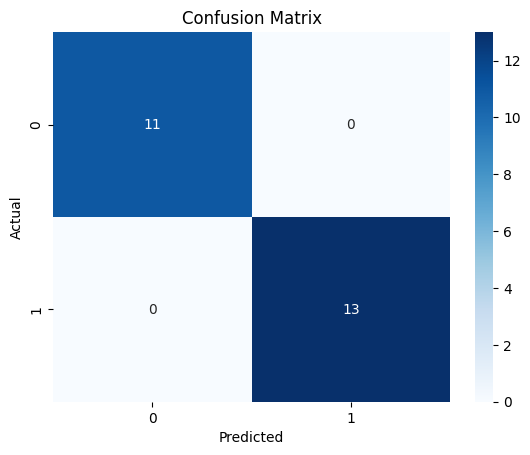

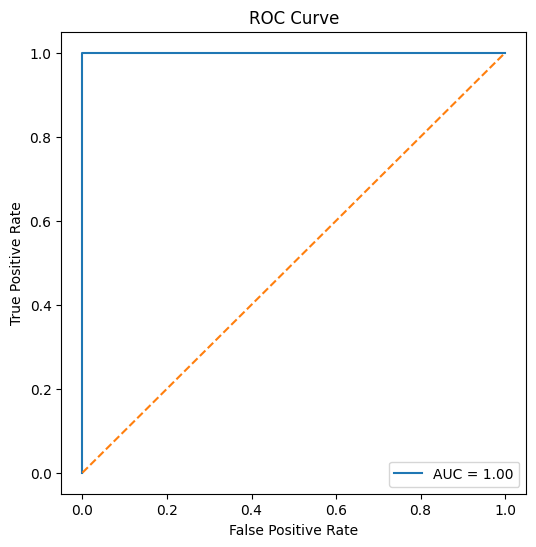

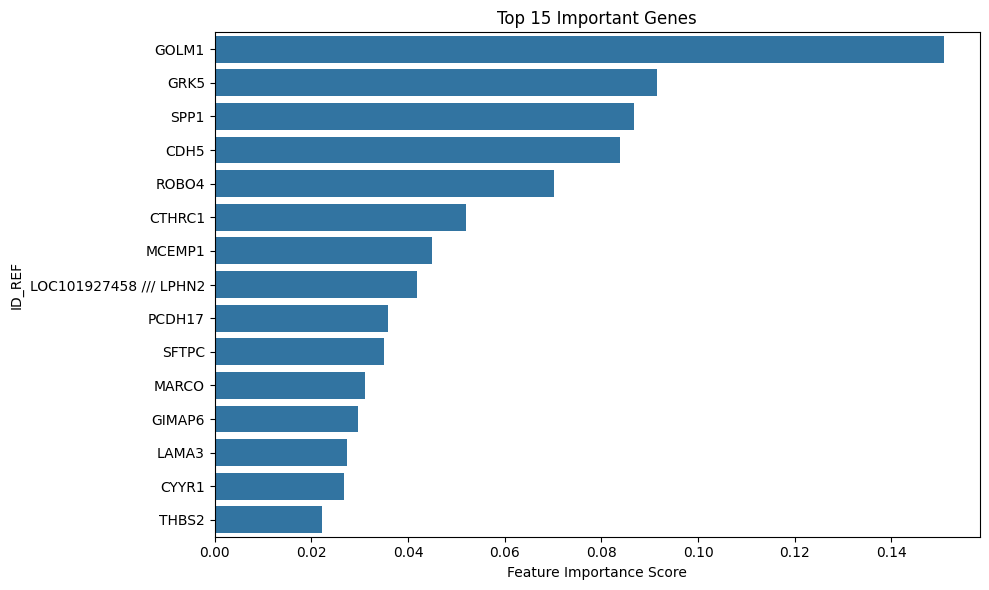

In [ ]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Model Training
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

#Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

#Evaluation
print(classification_report(y_test, y_pred))

#Confusion Matrix
conf_mat = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

#Feature Importance
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feature_importance[:15], y=feature_importance.index[:15])
plt.title("Top 15 Important Genes")
plt.xlabel("Feature Importance Score")
plt.tight_layout()
plt.show()


In [ ]:
#From above result , I think there is some overfitting , so I would be testing it on diffrent  larger dataset

Feature Selection

Top 10 Important Genes:
ID_REF
GOLM1                     0.150782
GRK5                      0.091472
SPP1                      0.086720
CDH5                      0.083823
ROBO4                     0.070215
CTHRC1                    0.051975
MCEMP1                    0.044938
LOC101927458 /// LPHN2    0.041858
PCDH17                    0.035771
SFTPC                     0.034985
dtype: float64


<ipython-input-35-f141fcdfb196>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genes.values, y=top_genes.index, palette="mako")


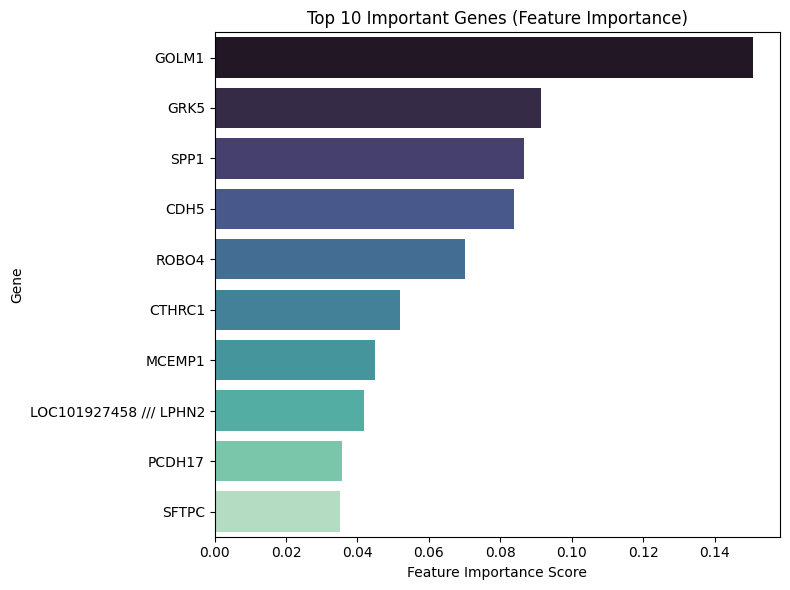

✅ Top 10 genes saved to 'Top_10_Important_Genes.csv'


In [ ]:
#Feature Selection Top Important Genes

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Get Feature Importance from your trained Random Forest model
feature_importance = pd.Series(model.feature_importances_, index=X.columns)

#Sort feature importance
feature_importance = feature_importance.sort_values(ascending=False)

#Display Top 10 Genes
top_genes = feature_importance.head(10)
print("Top 10 Important Genes:")
print(top_genes)

#Plot Top 10 Important Genes
plt.figure(figsize=(8,6))
sns.barplot(x=top_genes.values, y=top_genes.index, palette="mako")
plt.title("Top 10 Important Genes (Feature Importance)")
plt.xlabel("Feature Importance Score")
plt.ylabel("Gene")
plt.tight_layout()
plt.show()

#Save top genes to a csv
top_genes_df = pd.DataFrame(top_genes)
top_genes_df.columns = ["Importance"]
top_genes_df.to_csv("Top_10_Important_Genes.csv")

print("Top 10 genes saved to 'Top_10_Important_Genes.csv'")


Checking accuracy of model that is trained

In [ ]:
#Calculating Train Accuracy
train_preds = model.predict(X_train)
from sklearn.metrics import accuracy_score

train_accuracy = accuracy_score(y_train, train_preds)
print(f"Train Accuracy: {train_accuracy:.2f}")


Train Accuracy: 1.00


EXTERNAL VALIDATION

Classification Report (External Validation on GSE31210):
              precision    recall  f1-score   support

           0       0.58      0.90      0.71        20
           1       0.99      0.94      0.97       226

    accuracy                           0.94       246
   macro avg       0.79      0.92      0.84       246
weighted avg       0.96      0.94      0.94       246



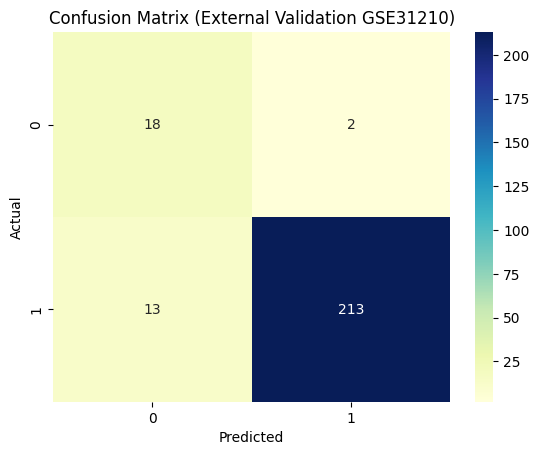

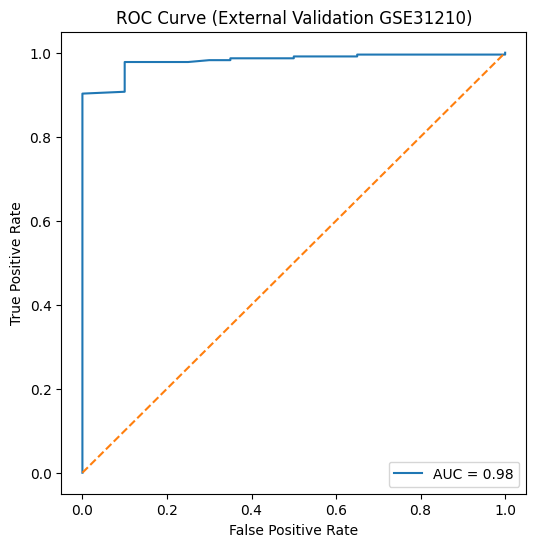

External Validation Accuracy (GSE31210): 0.94


In [ ]:
#As mentioned above , due to chances of overfitting , carrying external validation on Larger Dataset: GSE31210

#Load GSE31210
external_expr = expression_data["GSE31210"]

#Follow same steps ,rename Probe IDs to Gene Symbols
external_expr = external_expr.rename(index=dict(zip(mapped_df['Probe_ID'], mapped_df['Gene_Symbol'])))
external_expr = external_expr[external_expr.index != "Unknown"]

#Select only 37 DEGs
genes = mapped_df['Gene_Symbol'].dropna()
genes = genes[genes != "Unknown"].tolist()

external_selected = external_expr.loc[external_expr.index.intersection(genes)]
X_external = external_selected.T

#Prepare Labels
external_sample_labels = sample_labels["GSE31210"]
external_samples = X_external.index

y_external = [1 if external_sample_labels.get(sample) == "Tumor" else 0 for sample in external_samples]

#Predict using already trained model
y_pred_external = model.predict(X_external)
y_prob_external = model.predict_proba(X_external)[:,1]

#Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score, classification_report

print("Classification Report (External Validation on GSE31210):")
print(classification_report(y_external, y_pred_external))

#Confusion Matrix
conf_mat_ext = confusion_matrix(y_external, y_pred_external)
sns.heatmap(conf_mat_ext, annot=True, fmt='d', cmap='YlGnBu')
plt.title("Confusion Matrix (External Validation GSE31210)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#ROC Curve
fpr_ext, tpr_ext, _ = roc_curve(y_external, y_prob_external)
roc_auc_ext = roc_auc_score(y_external, y_prob_external)

plt.figure(figsize=(6,6))
plt.plot(fpr_ext, tpr_ext, label=f"AUC = {roc_auc_ext:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title("ROC Curve (External Validation GSE31210)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

#Print External Accuracy
ext_accuracy = accuracy_score(y_external, y_pred_external)
print(f"External Validation Accuracy (GSE31210): {ext_accuracy:.2f}")


Belwo work that have done is optional. ( Retraining model on small dataset )

In [ ]:
#Tried retraining Minimal Model on Top 5 Genes

#Subset X to top 5 genes
X_small = X[top_5_genes]

#Split into train/test
from sklearn.model_selection import train_test_split
X_train_small, X_test_small, y_train_small, y_test_small = train_test_split(X_small, y, test_size=0.2, random_state=42)

#Training Random Forest on Top 5 Genes
from sklearn.ensemble import RandomForestClassifier
minimal_model = RandomForestClassifier(n_estimators=100, random_state=42)
minimal_model.fit(X_train_small, y_train_small)

print("Minimal model retrained successfully!")


✅ Minimal model retrained successfully!


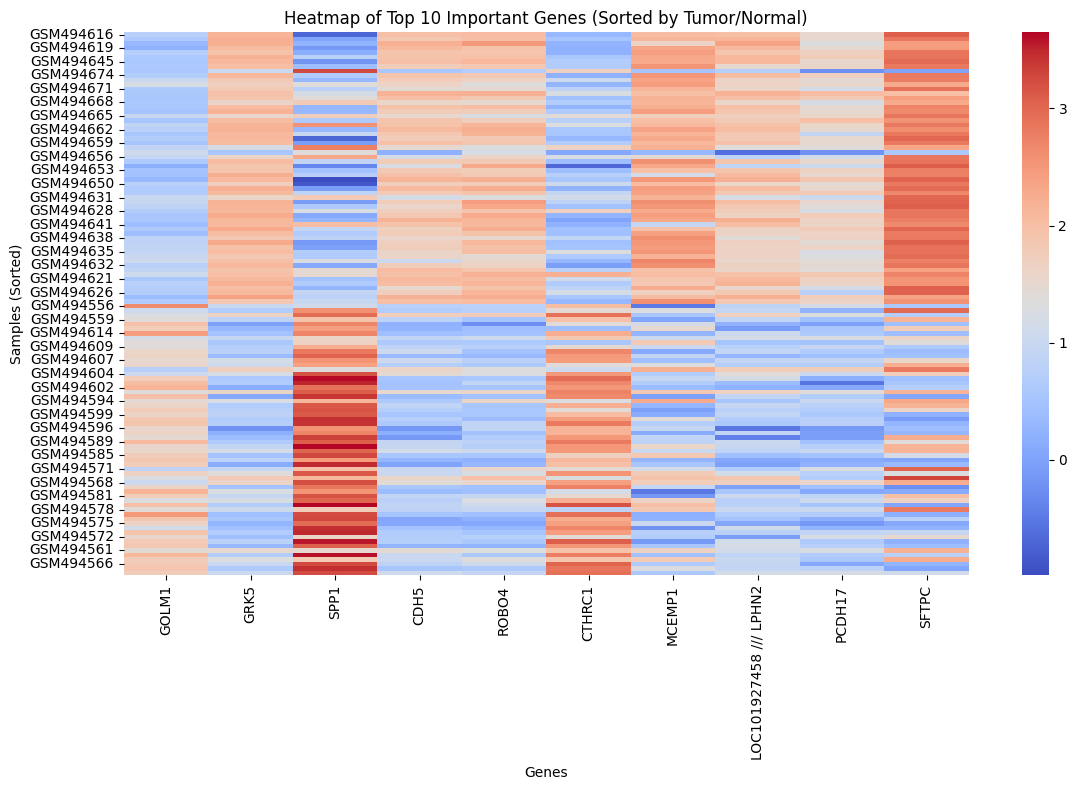

✅ Heatmap saved as 'Heatmap_Top10Genes.png'


In [ ]:
#Top 10 Genes from your feature importance)
top_10_genes = [
    'GOLM1',
    'GRK5',
    'SPP1',
    'CDH5',
    'ROBO4',
    'CTHRC1',
    'MCEMP1',
    'LOC101927458 /// LPHN2',
    'PCDH17',
    'SFTPC'
]

#Preparing Data
# X = full expression matrix with all samples and genes
X_top10 = X[top_10_genes].copy()

#Adding labels
heatmap_data = X_top10.copy()
heatmap_data['Label'] = y

#Sorting by label (Normal first, Tumor second), So that we could get cleaner visualization
heatmap_data = heatmap_data.sort_values(by='Label')

#Drop label column after sorting for heatmap
heatmap_data_top10 = heatmap_data.drop(columns=["Label"])

#Step 3: Plot Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(heatmap_data_top10, cmap='coolwarm', cbar=True)
plt.title("Heatmap of Top 10 Important Genes (Sorted by Tumor/Normal)")
plt.xlabel("Genes")
plt.ylabel("Samples (Sorted)")
plt.tight_layout()
plt.savefig("Heatmap_Top10Genes.png")
plt.show()

print("Heatmap saved as 'Heatmap_Top10Genes.png'")


ALL Optional from below

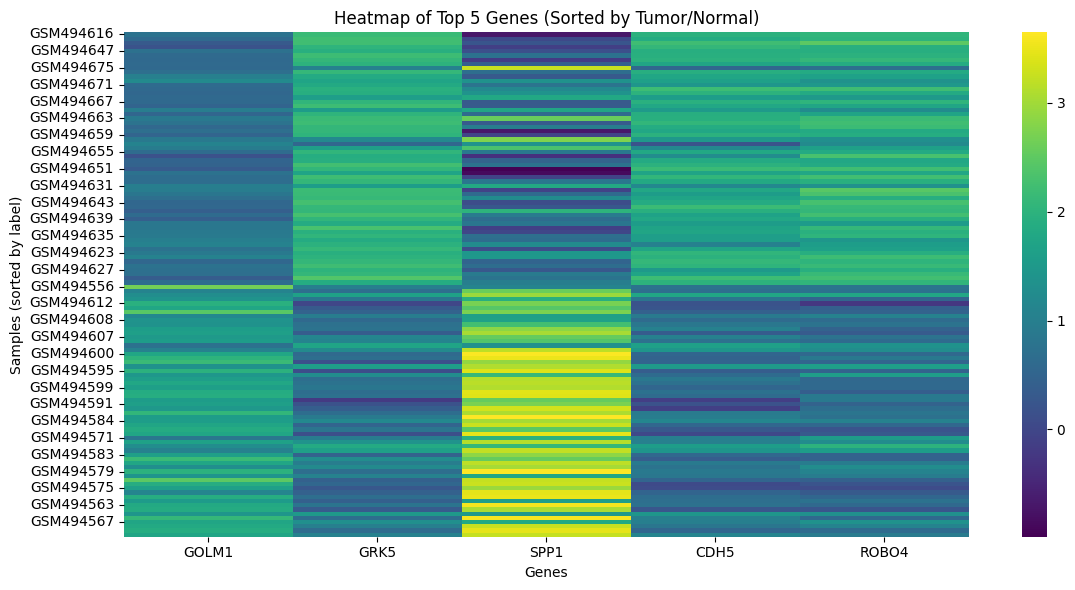

✅ Heatmap saved as 'Heatmap_Top5Genes.png'


In [ ]:
#Heatmap for Top 5 Genes
import seaborn as sns
import matplotlib.pyplot as plt

#X_small is already subset to Top 5 Genes
#y is the label vector (1 = Tumor, 0 = Normal)

#Creating dataframe for heatmap
heatmap_data = X_small.copy()
heatmap_data['Label'] = y

heatmap_data = heatmap_data.sort_values(by='Label')

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data[top_5_genes], cmap='viridis', cbar=True)
plt.title('Heatmap of Top 5 Genes (Sorted by Tumor/Normal)')
plt.xlabel('Genes')
plt.ylabel('Samples (sorted by label)')
plt.tight_layout()
plt.savefig("Heatmap_Top5Genes.png")
plt.show()

print(" Heatmap saved as 'Heatmap_Top5Genes.png'")
